# 02 — ML Experiments: 7 Sensor Variants + Cross-Age

Notebook nay chay toan bo thi nghiem:
1. Windowing + Feature extraction
2. Train RF / SVM / KNN voi GridSearchCV
3. 7 to hop cam bien (contribution chinh)
4. Cross-age evaluation (Train SA -> Test SE)
5. Ve bieu do + in bang ket qua


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from config import SENSOR_VARIANTS, TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SA, TEST_SE
from windowing import build_window_dataset, subject_split
from features import extract_features_batch, get_feature_names
from ml_models import MLTrainer, run_all_models, run_cross_age
from evaluate import (plot_sensor_variant_comparison, plot_cross_age_gap,
                       make_results_table, plot_feature_importance,
                       plot_confusion_matrix, plot_roc_curve)
print('Import xong!')

Import xong!


## Buoc 1: Doc du lieu va cat windows (ALL9 channels truoc)

In [2]:
# Doc tat ca subjects can thiet
all_subjects = TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SA + TEST_SE

X_all, y_all, meta_all = build_window_dataset(
    subjects=all_subjects,
    sensor_cols=SENSOR_VARIANTS['ALL9'],
    verbose=True,
)
print(f'X shape: {X_all.shape}  |  Fall: {(y_all==1).sum():,}  ADL: {(y_all==0).sum():,}')

Doc files: 100%|██████████| 38/38 [00:58<00:00,  1.53s/it]



Tong windows: 74,409
  Fall: 25,050  |  ADL: 49,359
  Shape X: (74409, 400, 9)
X shape: (74409, 400, 9)  |  Fall: 25,050  ADL: 49,359


In [3]:
# Chia train/val/test theo subject
splits = subject_split(X_all, y_all, meta_all)
print('\nSplits chi tiet:')
for name, sp in splits.items():
    if 'X' in sp:
        print(f'  {name:10s}: {sp["X"].shape}  Fall={( sp["y"]==1).sum()}  ADL={(sp["y"]==0).sum()}')

train: 44,046 windows | Fall=18,816 ADL=25,230 | subjects=18
val  :  7,276 windows | Fall=3,102 ADL=4,174 | subjects=3
test : 23,087 windows | Fall=3,132 ADL=19,955 | subjects=17

Splits chi tiet:
  train     : (44046, 400, 9)  Fall=18816  ADL=25230
  val       : (7276, 400, 9)  Fall=3102  ADL=4174
  test      : (23087, 400, 9)  Fall=3132  ADL=19955
  test_SA   : (4901, 400, 9)  Fall=2088  ADL=2813
  test_SE   : (18186, 400, 9)  Fall=1044  ADL=17142


## Buoc 2: Trich xuat dac trung (Feature Extraction)

In [4]:
sensor_cols = SENSOR_VARIANTS['ALL9']
feat_names  = get_feature_names(sensor_cols)
print(f'So dac trung: {len(feat_names)}')

X_tr_f = extract_features_batch(splits['train']['X'], sensor_cols)
X_va_f = extract_features_batch(splits['val']['X'],   sensor_cols, verbose=False)
X_te_f = extract_features_batch(splits['test']['X'],  sensor_cols, verbose=False)

print(f'Feature matrix train: {X_tr_f.shape}')

So dac trung: 126


Extract features: 100%|██████████| 44046/44046 [07:19<00:00, 100.14it/s]


Feature shape: (44046, 126) (126 features/window)
Feature matrix train: (44046, 126)


## Buoc 3: Train Random Forest voi GridSearchCV

Day la vi du chay don le. Phan 4 se chay tat ca model + tat ca variants.


In [5]:
# Train RF voi GridSearchCV
rf_trainer = MLTrainer(model_name='RF')
rf_trainer.fit(X_tr_f, splits['train']['y'], verbose=1)

print('\nBest parameters tim duoc:')
print(rf_trainer.best_params_)


  GridSearchCV: RF  |  5-fold CV
  Train: (44046, 126)  |  Fall:18816  ADL:25230
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV F1:  0.9236
Train time:  7148.0s

Best parameters tim duoc:
{'clf__class_weight': None, 'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}



--- RF | Val ---
[RF] Accuracy:    0.8608  (86.08%)
[RF] Sensitivity: 0.7750  (phat hien Fall)
[RF] Specificity: 0.9245  (nhan dung ADL)
[RF] Precision:   0.8841
[RF] F1-score:    0.8260
[RF] AUC-ROC:     0.9329
[RF] CM: TP=2404 TN=3859 FP=315 FN=698

--- RF | Test ---
[RF] Accuracy:    0.8573  (85.73%)
[RF] Sensitivity: 0.7877  (phat hien Fall)
[RF] Specificity: 0.8682  (nhan dung ADL)
[RF] Precision:   0.4840
[RF] F1-score:    0.5996
[RF] AUC-ROC:     0.9041
[RF] CM: TP=2467 TN=17325 FP=2630 FN=665
Da luu: d:\8. 9.5 Dataset\results\figures\cm_RF_ALL9.png


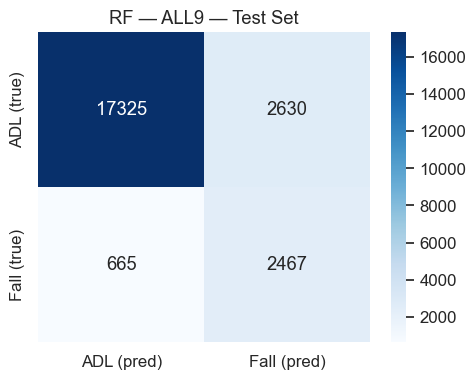

In [6]:
# Danh gia tren tap Val va Test
val_metrics  = rf_trainer.evaluate(X_va_f, splits['val']['y'],  'Val')
test_metrics = rf_trainer.evaluate(X_te_f, splits['test']['y'], 'Test')

# Confusion matrix
y_pred_test = rf_trainer.pipeline_.predict(X_te_f)
plot_confusion_matrix(splits['test']['y'], y_pred_test,
                       title='RF — ALL9 — Test Set',
                       save_name='cm_RF_ALL9.png')

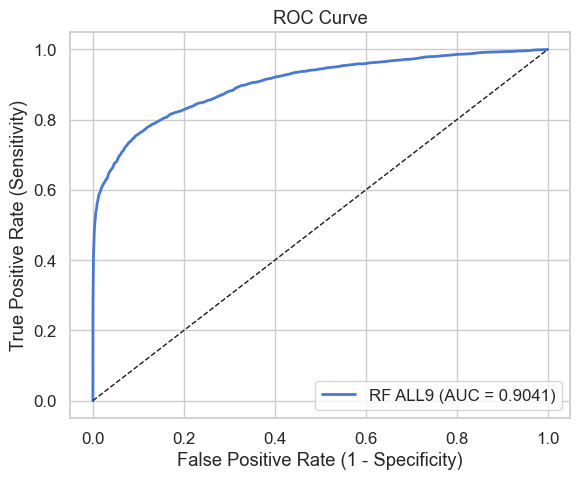

In [7]:
# ROC Curve
y_prob_test = rf_trainer.pipeline_.predict_proba(X_te_f)[:, 1]
plot_roc_curve(splits['test']['y'], y_prob_test, label='RF ALL9', save_name='roc_RF_ALL9.png')

Da luu: d:\8. 9.5 Dataset\results\figures\feature_importance_RF_ALL9.png


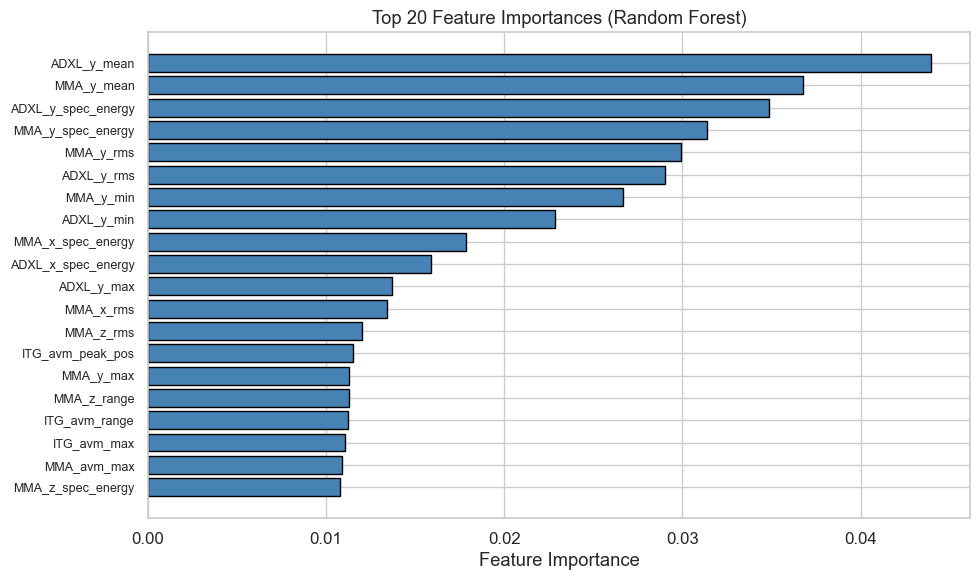

In [8]:
# Feature importance
plot_feature_importance(rf_trainer.pipeline_, feat_names, top_n=20,
                         save_name='feature_importance_RF_ALL9.png')

## Buoc 4: Thi nghiem 7 Sensor Variants

Day la contribution chinh: so sanh tat ca 7 to hop cam bien.
Chay tat ca model (RF, SVM, KNN) voi GridSearchCV cho moi variant.

**Luu y:** Cell nay mat khoang 30-60 phut. Co the chay qua dem.


In [1]:
all_results = []

for variant_name, sensor_cols in SENSOR_VARIANTS.items():
    print(f'\n{"="*50}')
    print(f'SENSOR VARIANT: {variant_name}  ({len(sensor_cols)} kenh)')
    print(f'{"="*50}')

    # Cat windows voi dung sensor cols
    X_v, y_v, meta_v = build_window_dataset(
        subjects=all_subjects,
        sensor_cols=sensor_cols,
        verbose=False)

    sp = subject_split(X_v, y_v, meta_v, verbose=False if variant_name!='ADXL' else True)

    # Feature extraction
    Xtr = extract_features_batch(sp['train']['X'], sensor_cols, verbose=False)
    Xva = extract_features_batch(sp['val']['X'],   sensor_cols, verbose=False)
    Xte = extract_features_batch(sp['test']['X'],  sensor_cols, verbose=False)

    # Chay 3 models
    res = run_all_models(
        Xtr, sp['train']['y'],
        Xva, sp['val']['y'],
        Xte, sp['test']['y'],
        experiment_name=f'variant_{variant_name}',
        save_models=True,
    )
    all_results.append(res)

intra_results = pd.concat(all_results, ignore_index=True)
intra_results.to_csv('../results/metrics/intra_age_results.csv', index=False)
print('\nXong! Da luu ket qua.')

NameError: name 'SENSOR_VARIANTS' is not defined

In [ ]:
# Hien thi bang ket qua test set
test_df = intra_results[intra_results['split']=='Test']
pivot = test_df.pivot_table(
    index='experiment', columns='model',
    values=['accuracy','sensitivity','specificity','f1'],
    aggfunc='mean'
).round(4)
print(pivot.to_string())

In [ ]:
# Ve bieu do so sanh sensor variants
plot_sensor_variant_comparison(
    intra_results,
    metric='f1',
    split='Test',
    save_name='fig_sensor_comparison.png'
)

## Buoc 5: Cross-Age Evaluation (Train SA -> Test SE)

In [ ]:
all_SA = TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SA  # tat ca 23 SA
all_SE = TEST_SE                                    # tat ca 15 SE

cross_results = []
for variant_name, sensor_cols in SENSOR_VARIANTS.items():
    print(f'Cross-age: {variant_name}')
    X_sa, y_sa, _ = build_window_dataset(subjects=all_SA, sensor_cols=sensor_cols, verbose=False)
    X_se, y_se, _ = build_window_dataset(subjects=all_SE, sensor_cols=sensor_cols, verbose=False)

    Xsa_f = extract_features_batch(X_sa, sensor_cols, verbose=False)
    Xse_f = extract_features_batch(X_se, sensor_cols, verbose=False)

    res = run_cross_age(Xsa_f, y_sa, Xse_f, y_se, sensor_variant=variant_name)
    cross_results.append(res)

cross_df = pd.concat(cross_results, ignore_index=True)
cross_df.to_csv('../results/metrics/cross_age_results.csv', index=False)
print('Xong cross-age!')

In [ ]:
# Ve bieu do cross-age gap
intra_test = intra_results[intra_results['split']=='Test'].copy()
intra_test['experiment'] = intra_test['experiment'].str.replace('variant_','')

plot_cross_age_gap(intra_test, cross_df, save_name='fig_cross_age_gap.png')

## Buoc 6: Bang ket qua cuoi cung (paper-ready)

In [ ]:
# Bang intra-age (so sanh voi cac bai bao 2024-2025)
table_intra = make_results_table(intra_results, 'table_intra_age.csv')

# Hien thi nhu paper
best_per_variant = (
    table_intra[table_intra['split']=='Test']
    .sort_values('f1', ascending=False)
    .groupby('experiment')
    .first()
    .reset_index()
    [['experiment','model','accuracy','sensitivity','specificity','f1']]
)
print('\n=== Best model per sensor variant ===')
print(best_per_variant.to_string(index=False))

In [ ]:
# So sanh voi baseline papers (tu tay nhap so lieu tu bai bao)
paper_baselines = pd.DataFrame([
    {'Paper': 'Villa & Casilari 2025 (Sensors)', 'Model': 'CNN-LSTM',
     'Accuracy': 98.9, 'Sensitivity': 96.7, 'Specificity': 99.6, 'F1': None,
     'Input': 'ADXL only', 'Year': 2025},
    {'Paper': 'Kavuncuoglu 2024 (Comp.Intel.)', 'Model': 'ETC',
     'Accuracy': 98.69, 'Sensitivity': 98.28, 'Specificity': 99.08, 'F1': None,
     'Input': 'ADXL only', 'Year': 2024},
    {'Paper': 'Zhang et al. 2024 (JMIR)', 'Model': 'DSCS CNN+SA',
     'Accuracy': 99.32, 'Sensitivity': 99.15, 'Specificity': None, 'F1': 98.86,
     'Input': 'Accel+Gyro', 'Year': 2024},
])
print('\n=== Baseline papers (SisFall 2024-2025) ===')
print(paper_baselines.to_string(index=False))